In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from IPython.display import display, Markdown, Latex
import pandas as pd
from uncertainties import ufloat
from uncertainties import unumpy as unp
from scipy.optimize import curve_fit
from scipy import constants as const 
from uncertainties.umath import atan, degrees
import math
from uncertainties.umath import atan

# PW9 Wechselstrom II


### 1. Verwendete Formeln

Die komplexe Impedanz lässt sich durch folgende Formel berechnen:
$$
|X| = \ R_0 \cdot \sqrt{(\frac{U_1}{U_2})^2 - 1}
$$

<br>

Falls es sich um einen Ohm'schen Widerstand handelt: 
$$
R_x = R_0 \cdot (\frac{U_1}{U_2} - 1)
$$

<br> 

 Phasenverschiebung $\Delta \varphi$::
$$
\Delta \varphi = \arctan{\frac{X}{R_0}}
$$


### 2. Ergebnisse der Messung

In [15]:
#2.1
#Messungen und Berechnungen Ohm#scher Widerstand R

nü_R = 500 # in Hz
omega_R = 2 * const.pi * nü_R

R_0 = np.array([1790]) #in Ohm
R_0_u = ufloat(1790,0.1) # in Ohm
U_1_R = np.array([10.2]) # in Volt
U_2_R = np.array([2.40]) # in Volt

R_x = R_0 * ((U_1_R/U_2_R)-1) # in Ohm
R_x_u = ufloat(R_x,R_x * 0.05) # R_x mit Unsicherheit von 5%
delta_phi_R = 0

#2.2
#Messungen und Berechnungen Kondensator C

nü_C = 150 # in Hz
delta_t_C = 1.38 * 10**-3 # in s
omega_C = 2 * const.pi * nü_C
delta_phi_C_gemessen_rad = omega_C * delta_t_C
delta_phi_C_gemessen_rad_u = ufloat(delta_phi_C_gemessen_rad,delta_phi_C_gemessen_rad * 0.02)
delta_phi_C_gemessen_grad_u = ufloat(math.degrees(delta_phi_C_gemessen_rad), math.degrees(delta_phi_C_gemessen_rad) *0.02)


U_1_C = np.array([10.2]) # in Volt
U_2_C = np.array([3.32]) # in Volt

X_C = R_0 * np.sqrt(((U_1_C/U_2_C)**2)-1) # in Ohm
X_C_u = ufloat(X_C,X_C * 0.05)
C = 1/(omega_C * X_C) # in Farad
C_u = ufloat(C,C * 0.05)
delta_phi_C_rad_u = atan(-X_C_u/R_0_u)
delta_phi_C_grad_u = degrees(delta_phi_C_rad_u)

#2.3
#Messungen und Berechnungen Spule L

nü_L = 30000 #in Hz
delta_t_L = 4.8 * 10**-6 # in s
omega_L = 2 * const.pi * nü_L
delta_phi_L_gemessen_rad = omega_L * delta_t_L
delta_phi_L_gemessen_rad_u = ufloat(omega_L * delta_t_L,omega_L * delta_t_L * 0.02)
delta_phi_L_gemessen_grad_u = ufloat(math.degrees(delta_phi_L_gemessen_rad), math.degrees(delta_phi_L_gemessen_rad) * 0.02)

U_1_L = np.array([10.0]) # in Volt
U_2_L = np.array([6.32]) # in Volt

X_L = R_0 * np.sqrt(((U_1_L/U_2_L)**2)-1) # in Ohm
X_L_u = ufloat(X_L, X_L * 0.05)
L = X_L/omega_L # in Henry
L_u = ufloat(L, L * 0.05)
delta_phi_L_rad_u = atan(X_L_u/R_0_u)
delta_phi_L_grad_u = degrees(delta_phi_L_rad_u)

# Printen für R
print(f"R_x beträgt {R_x_u} Ohm")
print(f"Die Phasenverschiebung \u0394\u03D5 beträgt {delta_phi_R}\n")

# Printen für C
print(f"X_C beträgt {X_C_u} Ohm")
print(f"Die Kapazität des Kondensators C beträgt {C_u} Farad")
print(f"Die errechnete Phasenverschiebung \u0394\u03D5 beträgt {delta_phi_C_rad_u} in rad und {delta_phi_C_grad_u} in Grad(°)") 
print(f"Die gemessene Phasenverschiebung beträgt -{delta_phi_C_gemessen_rad_u} in rad und -{delta_phi_C_gemessen_grad_u} in Grad (°)\n")

# Printen für L
print(f"X_L beträgt {X_L_u:.3g} Ohm")
print(f"Die Induktivität der Spule L beträgt {L_u:.4g} Henry")
print(f"Die errechnete Phasenverschiebung \u0394\u03D5 beträgt {delta_phi_L_rad_u} in rad und {delta_phi_L_grad_u} in Grad (°)")
print(f"Die gemessene Phasenverschiebung beträgt {delta_phi_L_gemessen_rad_u} in rad und {delta_phi_L_gemessen_grad_u} in Grad (°)") 



R_x beträgt (5.82+/-0.29)e+03 Ohm
Die Phasenverschiebung Δϕ beträgt 0

X_C beträgt (5.20+/-0.26)e+03 Ohm
Die Kapazität des Kondensators C beträgt (2.04+/-0.10)e-07 Farad
Die errechnete Phasenverschiebung Δϕ beträgt -1.239+/-0.015 in rad und -71.0+/-0.9 in Grad(°)
Die gemessene Phasenverschiebung beträgt -1.301+/-0.026 in rad und -74.5+/-1.5 in Grad (°)

X_L beträgt (2.19+/-0.11)e+03 Ohm
Die Induktivität der Spule L beträgt 0.01164+/-0.00058 Henry
Die errechnete Phasenverschiebung Δϕ beträgt 0.887+/-0.024 in rad und 50.8+/-1.4 in Grad (°)
Die gemessene Phasenverschiebung beträgt 0.905+/-0.018 in rad und 51.8+/-1.0 in Grad (°)


### 3. Anhang

Die im XY Betrieb angezeigten Kurven:


Für den Ohm'schen Widerstand:

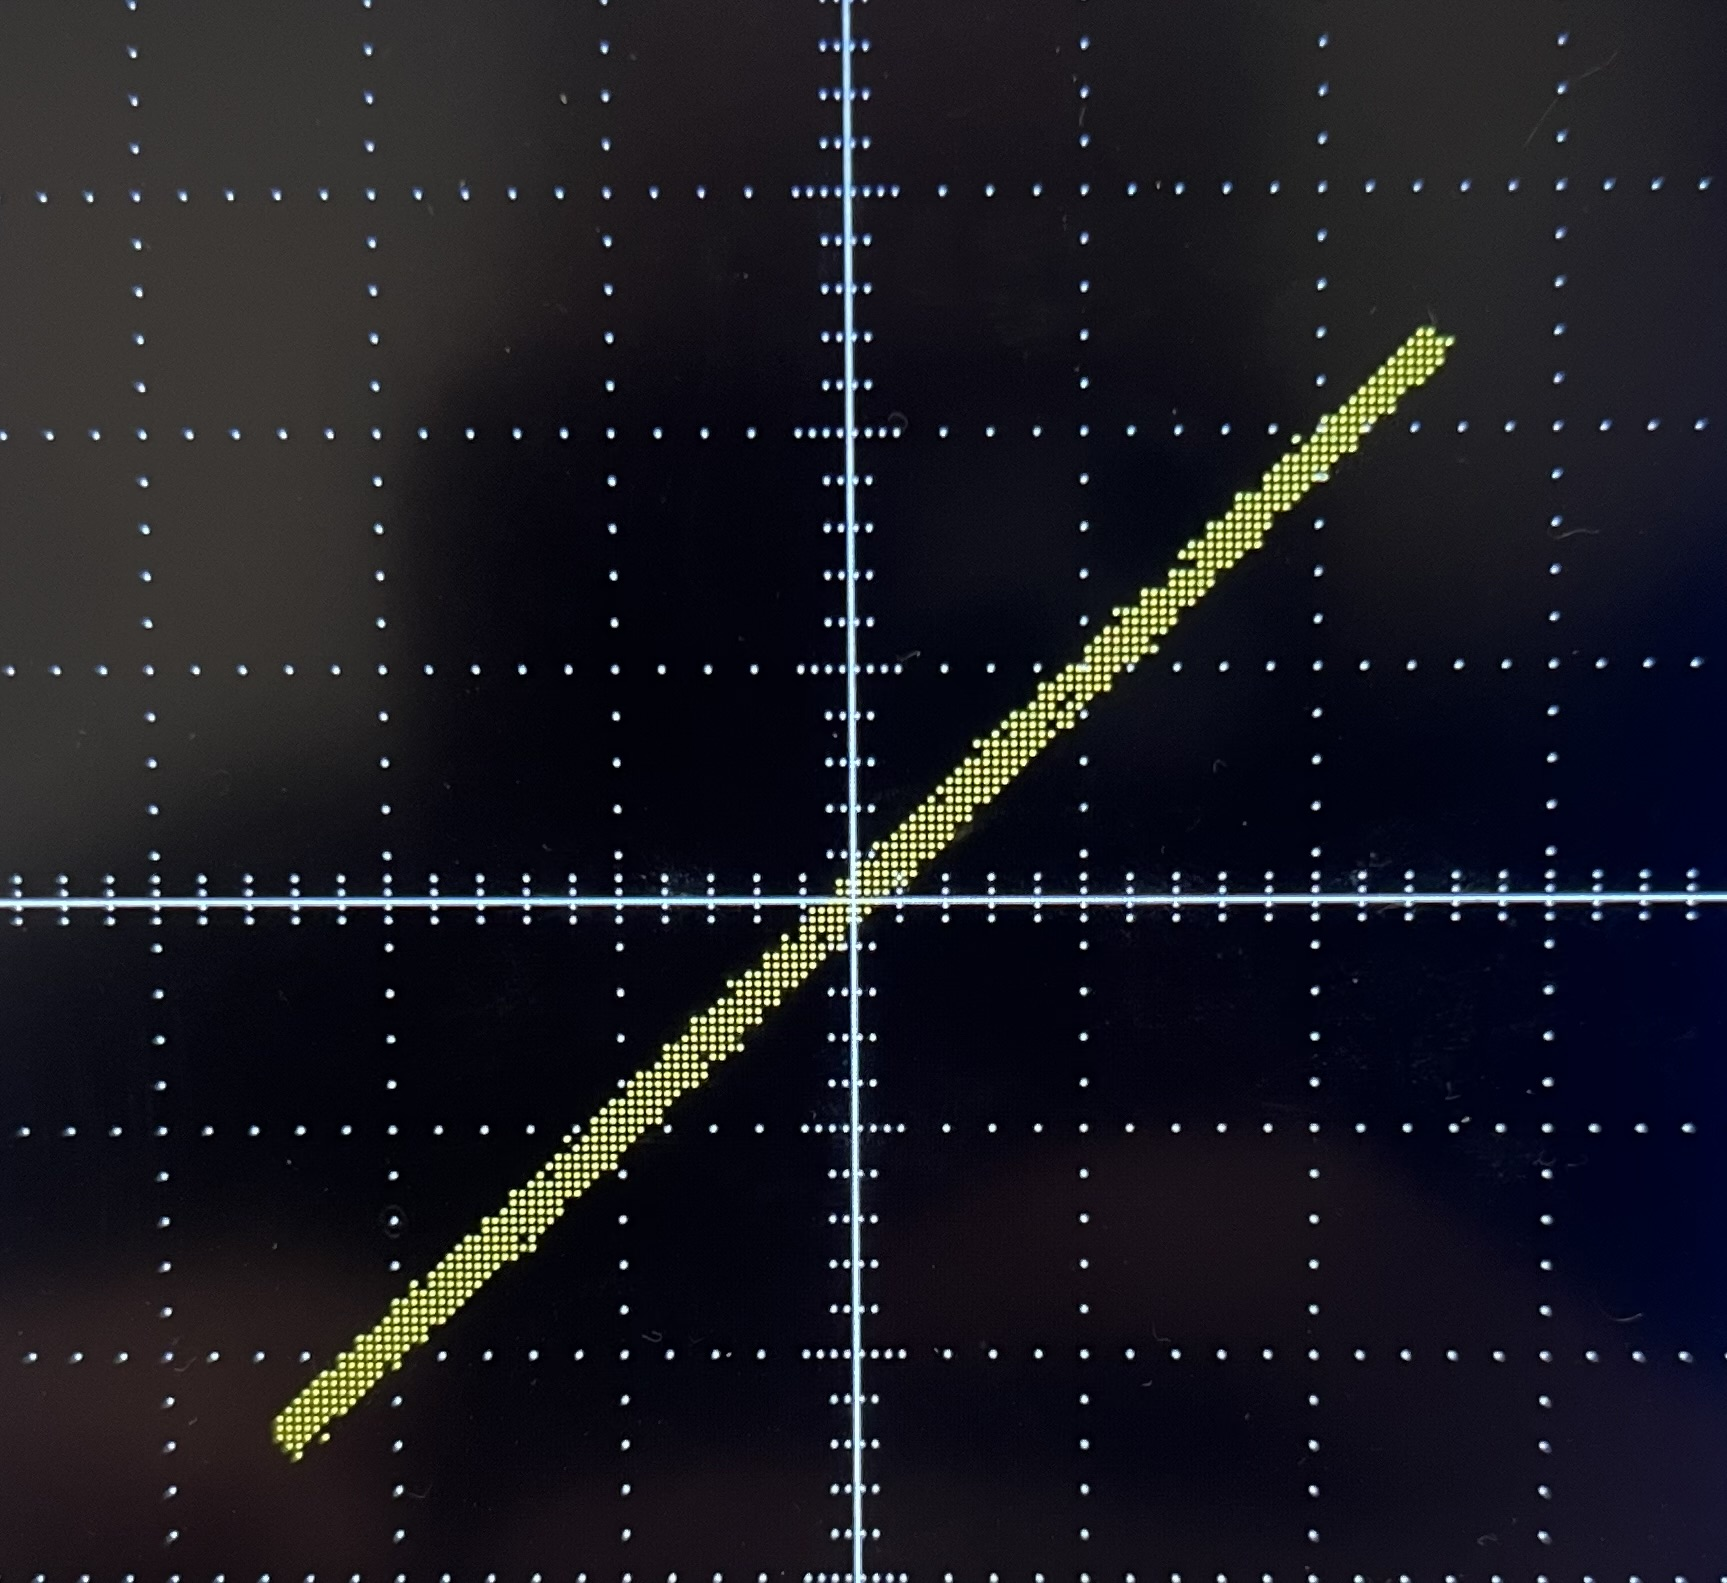

Für den Kondensator: 

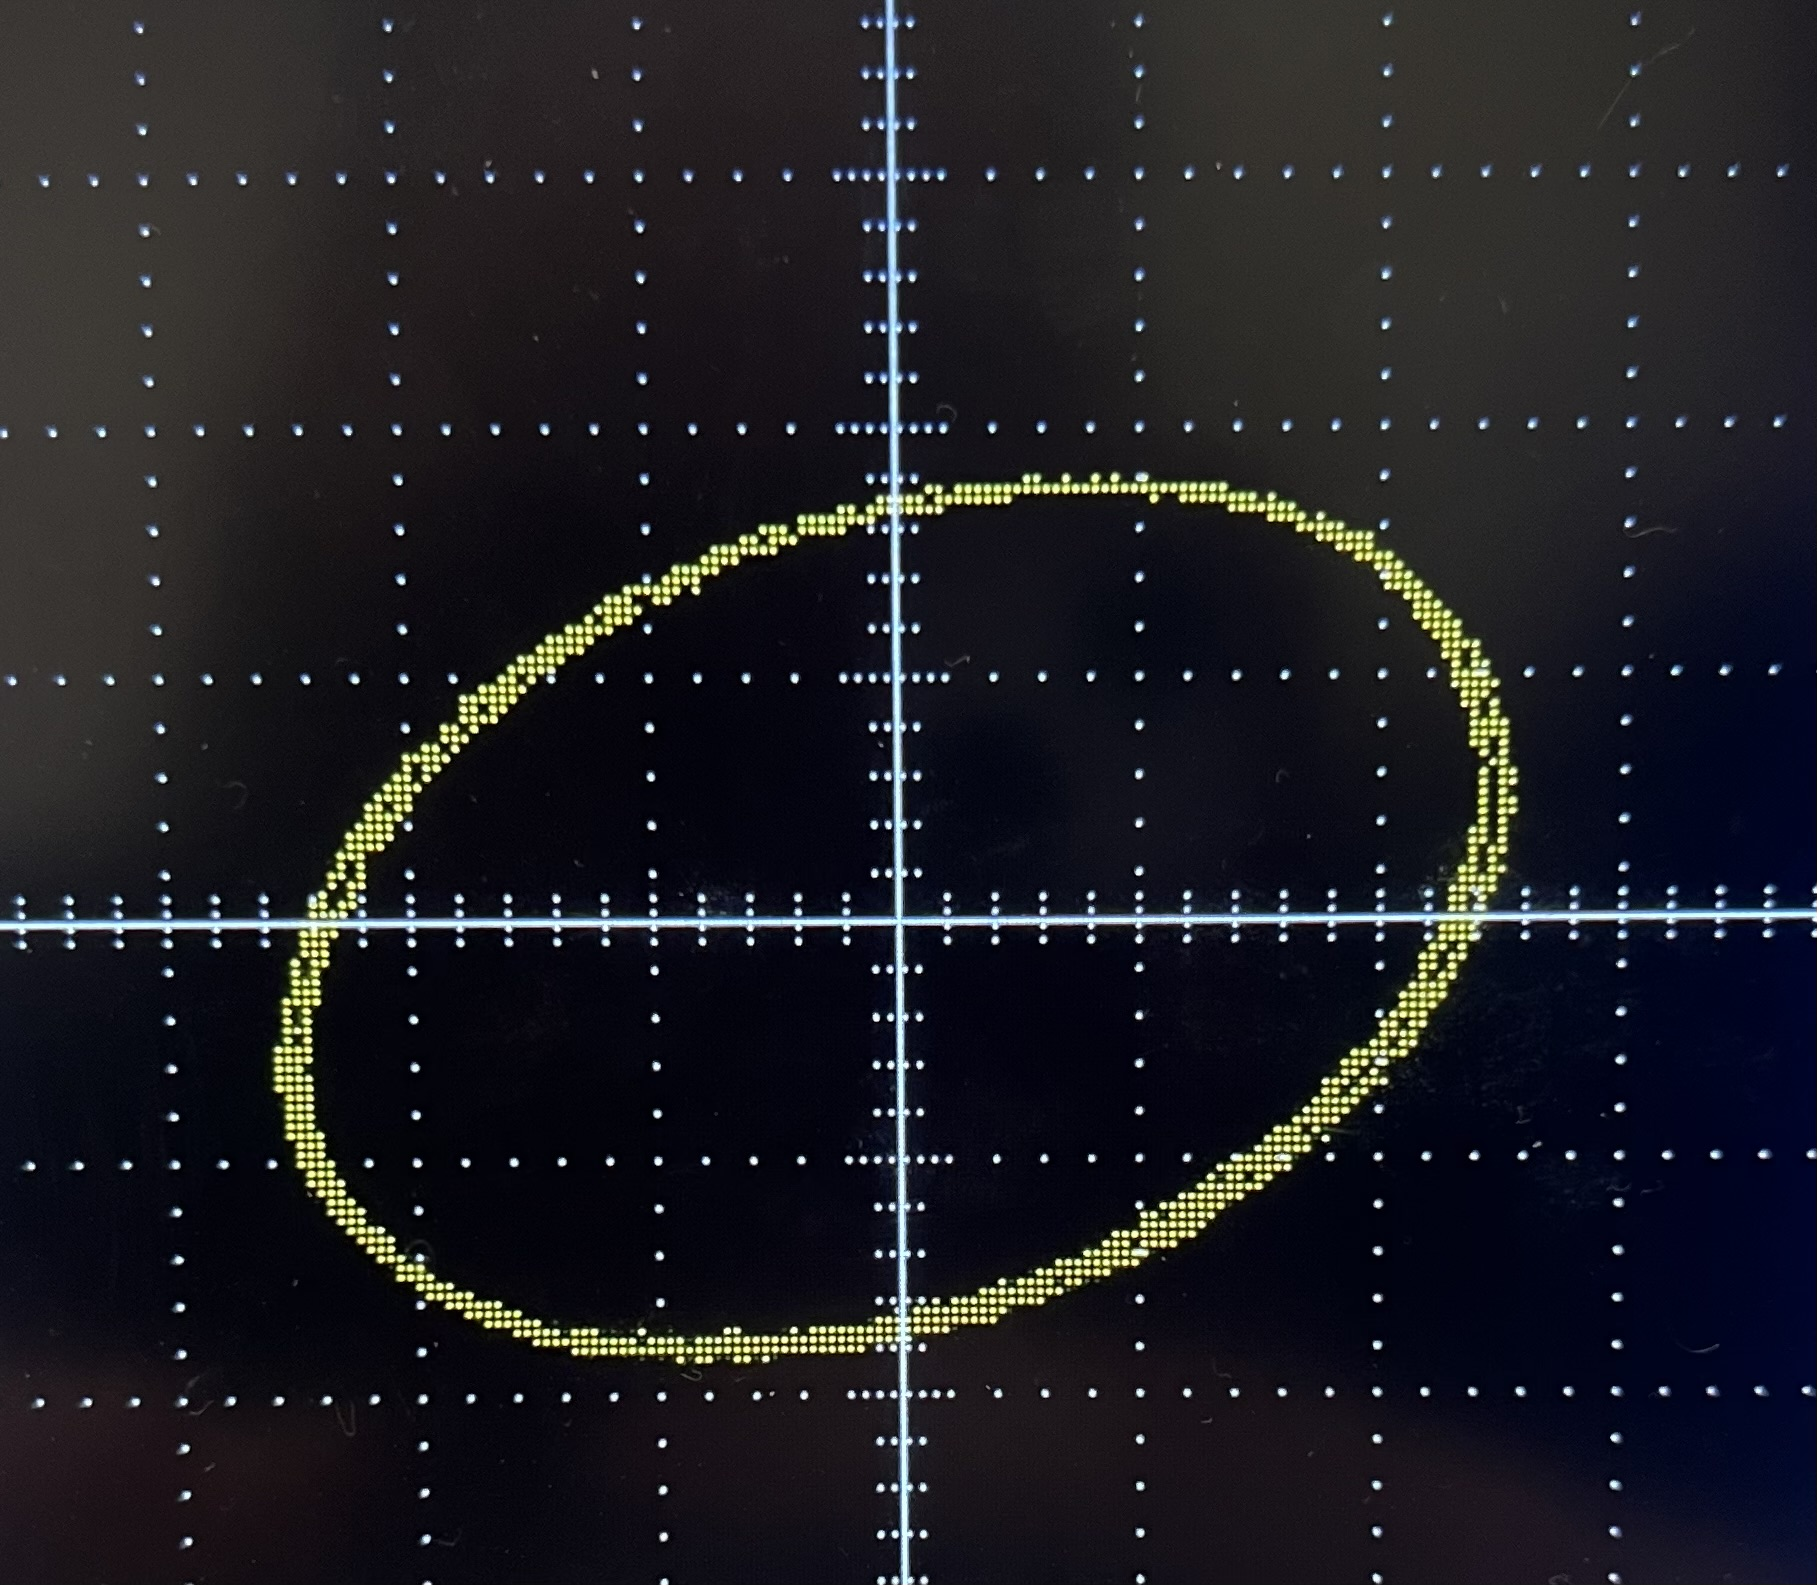

Für die Spule: 

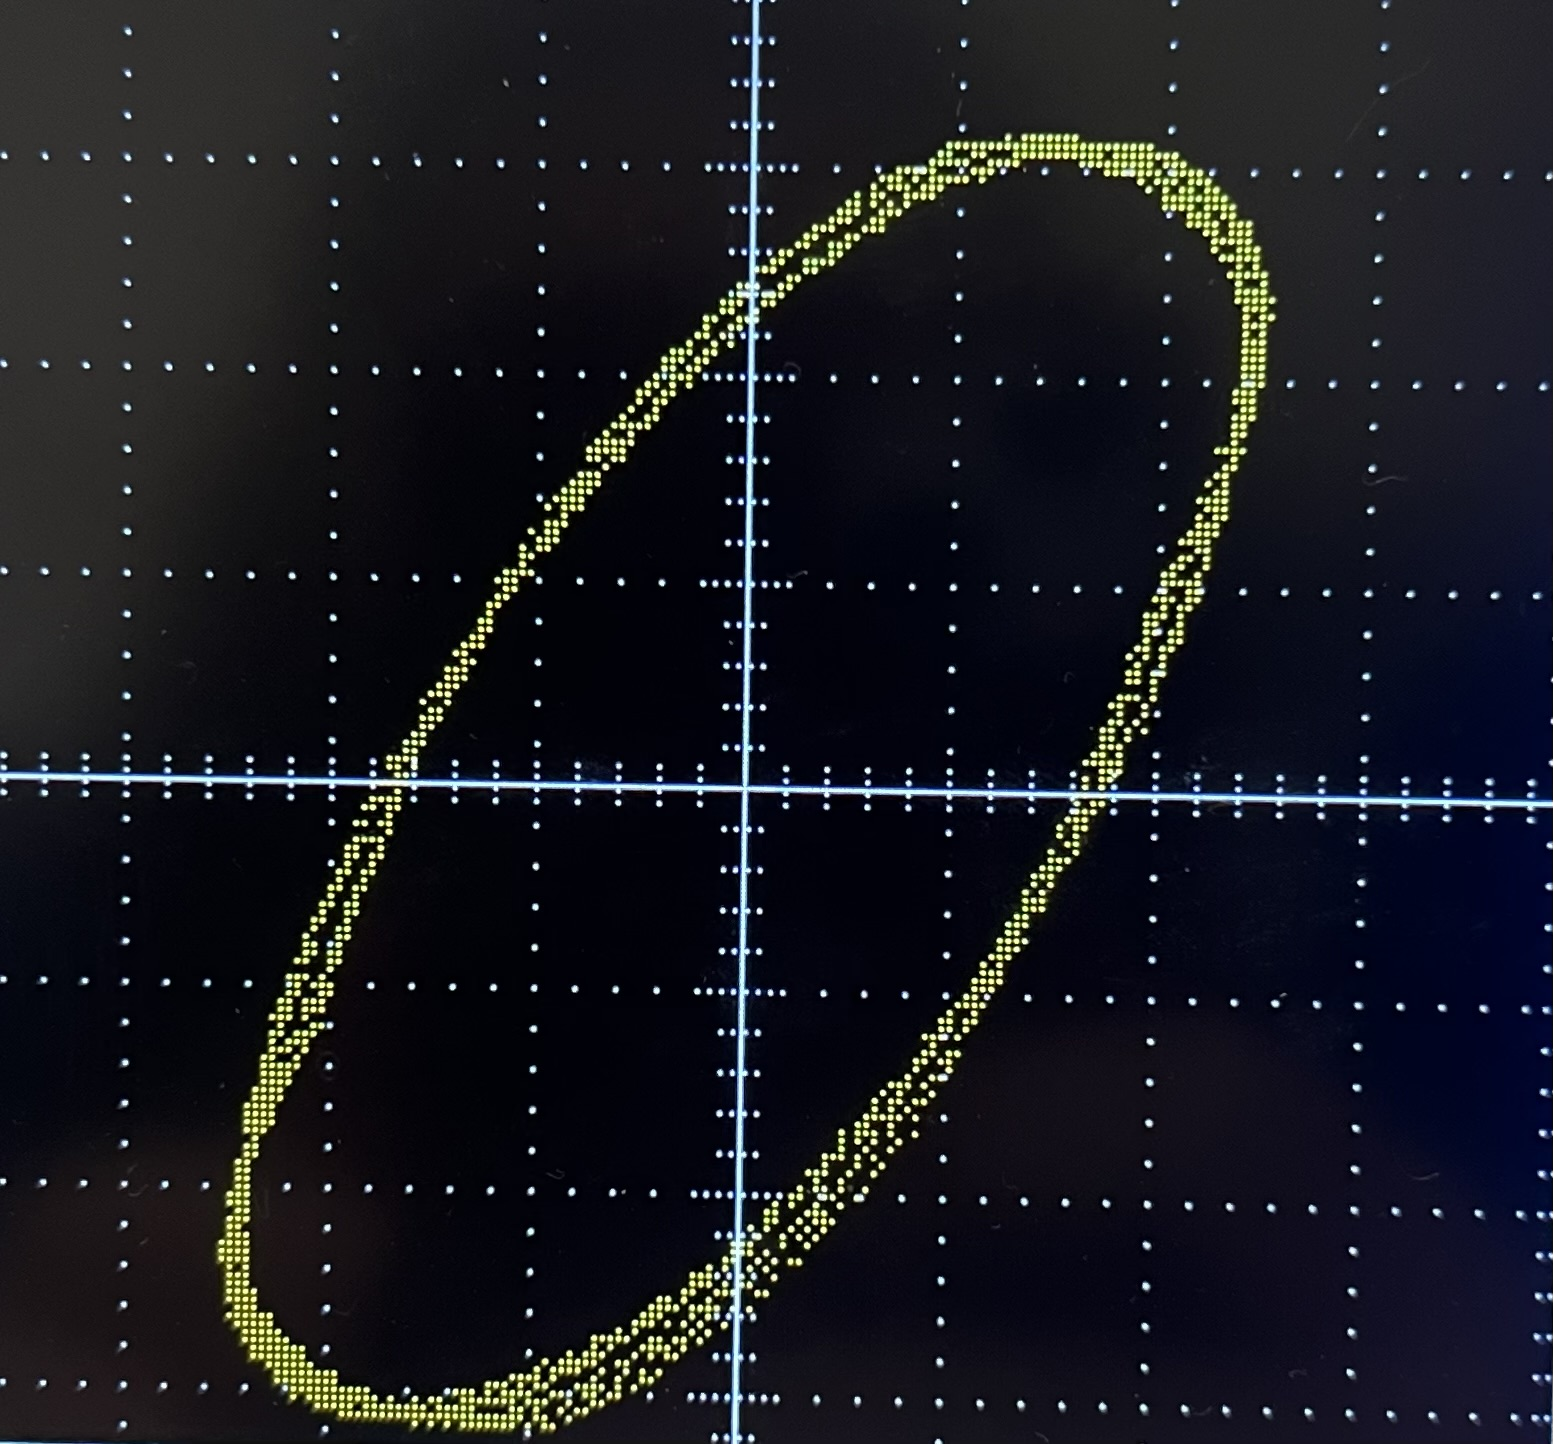



Die Skizze für den Versuchsaufbau mit dem Ohm'schen Widerstand:

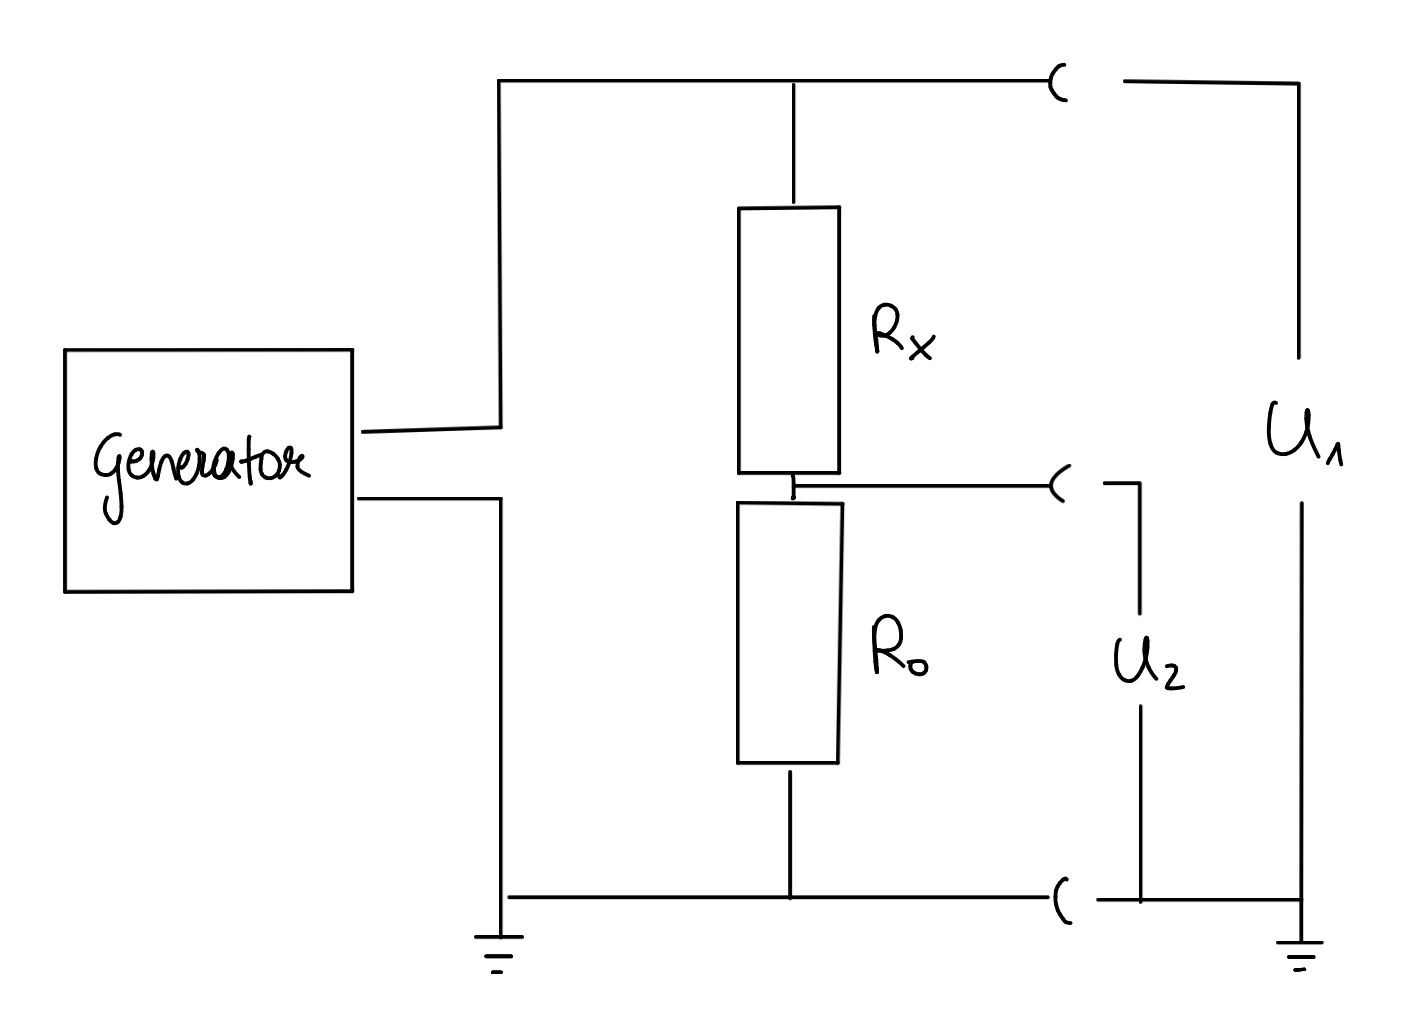

Die Skizze für den Versuchsaufbau mit dem Kondensator:

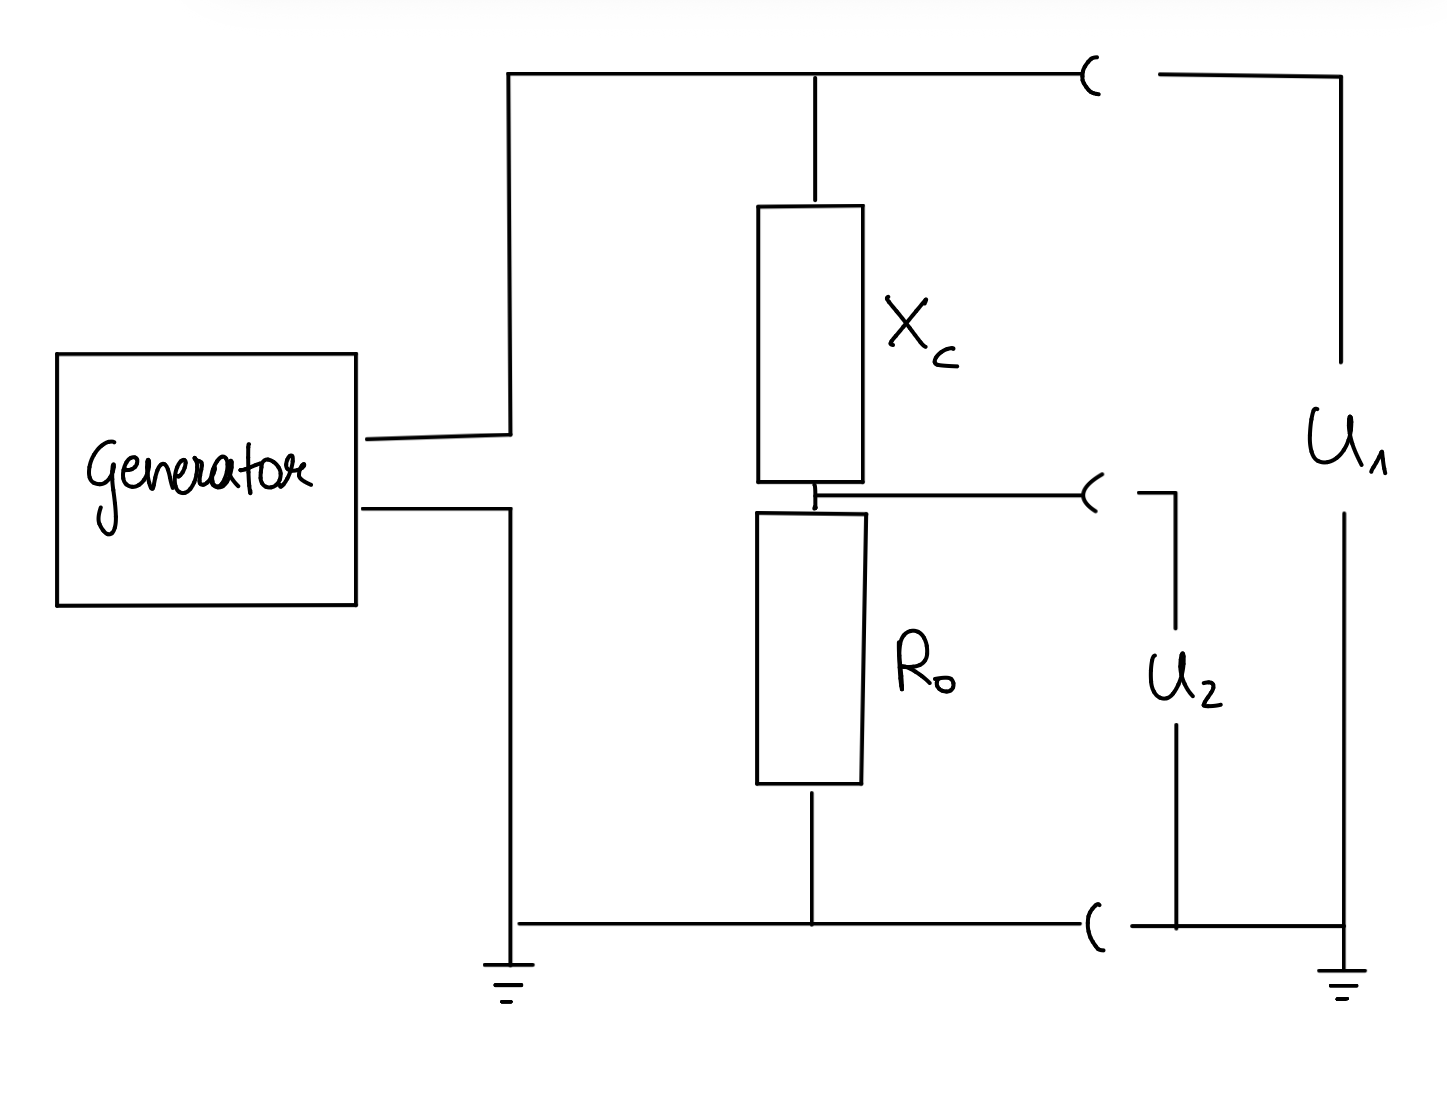

Die Skizze für den Versuchsaufbau mit der Spule:

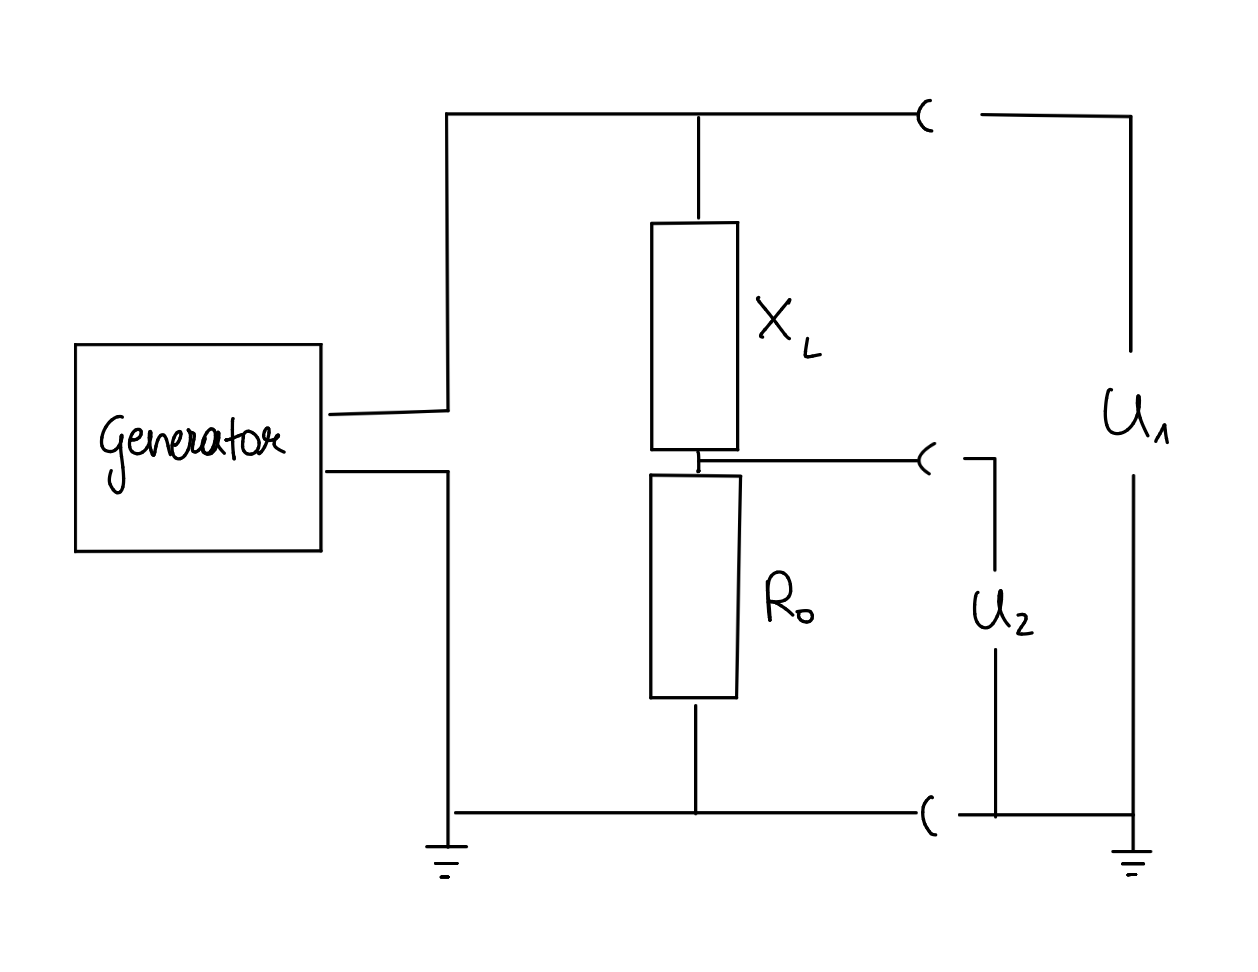